# Week 2: Data Collection, Cleaning, and Preprocessing for Logistics Analysis

**Internship Organization:** YuvaIntern  
**Internship Role:** Logistics Data Analyst Intern  
**Name:** SATHYALA MAHAMMED  
**College:** Bhimavaram Institute of Engineering and Technology  
**Branch:** Electronics and Communication Engineering (ECE)

## Objective
This week focuses on data collection, data quality assessment, missing value handling,
outlier detection, normalization, and preprocessing of logistics data using Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Week 1 dataset folder
data_path = r"C:\Users\satha\OneDrive\Desktop\YuvaIntern-Week1-Logistics-Strategic-Planning"

orders = pd.read_csv(data_path + r"\olist_orders_dataset.csv")
order_items = pd.read_csv(data_path + r"\olist_order_items_dataset.csv")
customers = pd.read_csv(data_path + r"\olist_customers_dataset.csv")
sellers = pd.read_csv(data_path + r"\olist_sellers_dataset.csv")
products = pd.read_csv(data_path + r"\olist_products_dataset.csv")
payments = pd.read_csv(data_path + r"\olist_order_payments_dataset.csv")
reviews = pd.read_csv(data_path + r"\olist_order_reviews_dataset.csv")
geolocation = pd.read_csv(data_path + r"\olist_geolocation_dataset.csv")
category_translation = pd.read_csv(data_path + r"\product_category_name_translation.csv")

print("All datasets loaded successfully!")
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)
print("Sellers:", sellers.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Geolocation:", geolocation.shape)

All datasets loaded successfully!
Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 5)
Sellers: (3095, 4)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)
Geolocation: (1000163, 5)


In [4]:
datasets = {
    "Orders": orders,
    "Order Items": order_items,
    "Customers": customers,
    "Sellers": sellers,
    "Products": products,
    "Payments": payments,
    "Reviews": reviews,
    "Geolocation": geolocation,
    "Category Translation": category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 5)
Sellers: (3095, 4)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)
Geolocation: (1000163, 5)
Category Translation: (71, 2)


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
missing_values = orders.isnull().sum()

print("Missing values in Orders dataset:")
print(missing_values)

Missing values in Orders dataset:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [7]:
missing_percentage = (
    orders.isnull().sum() / len(orders) * 100
).sort_values(ascending=False)

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
order_delivered_customer_date    2.981668
order_delivered_carrier_date     1.793023
order_approved_at                0.160899
order_id                         0.000000
order_purchase_timestamp         0.000000
order_status                     0.000000
customer_id                      0.000000
order_estimated_delivery_date    0.000000
dtype: float64


In [8]:
duplicate_count = orders.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [9]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

print("Date columns converted successfully!")
print(orders[date_columns].dtypes)

Date columns converted successfully!
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [10]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

print(orders["delivery_days"].describe())

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64


In [11]:
print("Missing delivery days:",
      orders["delivery_days"].isnull().sum())


Missing delivery days: 2965


In [12]:
orders_clean = orders.dropna(
    subset=["delivery_days"]
).copy()

print("Original records:", len(orders))
print("After removing missing delivery time:", len(orders_clean))

Original records: 99441
After removing missing delivery time: 96476


In [13]:
invalid_delivery = orders_clean[
    orders_clean["delivery_days"] < 0
]

print("Negative delivery time records:",
      len(invalid_delivery))

Negative delivery time records: 0


In [14]:
orders_clean = orders_clean[
    orders_clean["delivery_days"] >= 0
].copy()

print("Invalid delivery times removed.")
print("Current records:", len(orders_clean))

Invalid delivery times removed.
Current records: 96476


In [15]:
Q1 = orders_clean["delivery_days"].quantile(0.25)
Q3 = orders_clean["delivery_days"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 6.766403356481481
Q3: 15.720326967592593
IQR: 8.953923611111112
Lower Bound: -6.664482060185186
Upper Bound: 29.15121238425926


In [16]:
outliers = orders_clean[
    (orders_clean["delivery_days"] < lower_bound) |
    (orders_clean["delivery_days"] > upper_bound)
]

print("Potential delivery-time outliers:",
      len(outliers))

Potential delivery-time outliers: 4899


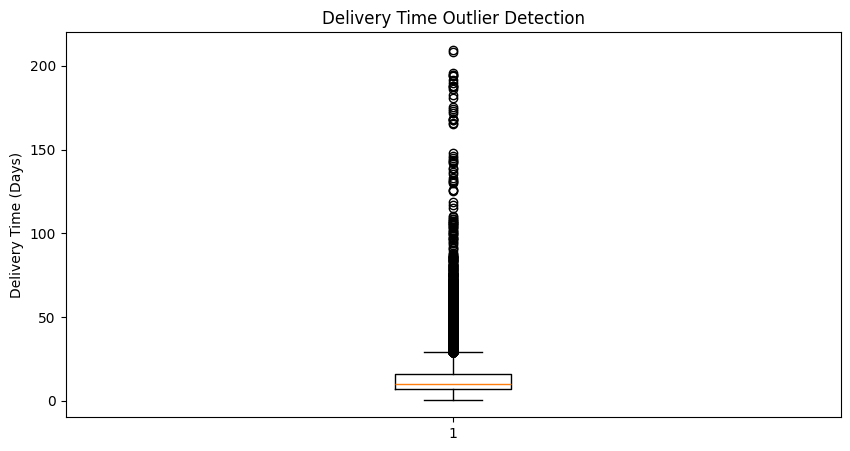

In [17]:
plt.figure(figsize=(10, 5))

plt.boxplot(orders_clean["delivery_days"])

plt.title("Delivery Time Outlier Detection")
plt.ylabel("Delivery Time (Days)")
plt.show()

In [18]:
orders_processed = orders_clean[
    (orders_clean["delivery_days"] >= lower_bound) &
    (orders_clean["delivery_days"] <= upper_bound)
].copy()

print("Before outlier removal:", len(orders_clean))
print("After outlier removal:", len(orders_processed))

Before outlier removal: 96476
After outlier removal: 91577


In [19]:
orders_processed["is_late"] = (
    orders_processed["order_delivered_customer_date"]
    > orders_processed["order_estimated_delivery_date"]
).astype(int)

print(orders_processed["is_late"].value_counts())

is_late
0    87665
1     3912
Name: count, dtype: int64


In [20]:
late_rate = orders_processed["is_late"].mean() * 100
on_time_rate = 100 - late_rate

print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")
print(f"Late Delivery Rate: {late_rate:.2f}%")

On-Time Delivery Rate: 95.73%
Late Delivery Rate: 4.27%


In [21]:
scaler = MinMaxScaler()

orders_processed["delivery_days_normalized"] = (
    scaler.fit_transform(
        orders_processed[["delivery_days"]]
    )
)

print(
    orders_processed[
        ["delivery_days", "delivery_days_normalized"]
    ].head()
)

   delivery_days  delivery_days_normalized
0       8.436574                  0.276178
1      13.782037                  0.462977
2       9.394213                  0.309643
3      13.208750                  0.442943
4       2.873877                  0.081788


In [22]:
standard_scaler = StandardScaler()

orders_processed["delivery_days_standardized"] = (
    standard_scaler.fit_transform(
        orders_processed[["delivery_days"]]
    )
)

print(
    orders_processed[
        ["delivery_days", "delivery_days_standardized"]
    ].head()
)

   delivery_days  delivery_days_standardized
0       8.436574                   -0.429053
1      13.782037                    0.448935
2       9.394213                   -0.271761
3      13.208750                    0.354773
4       2.873877                   -1.342721


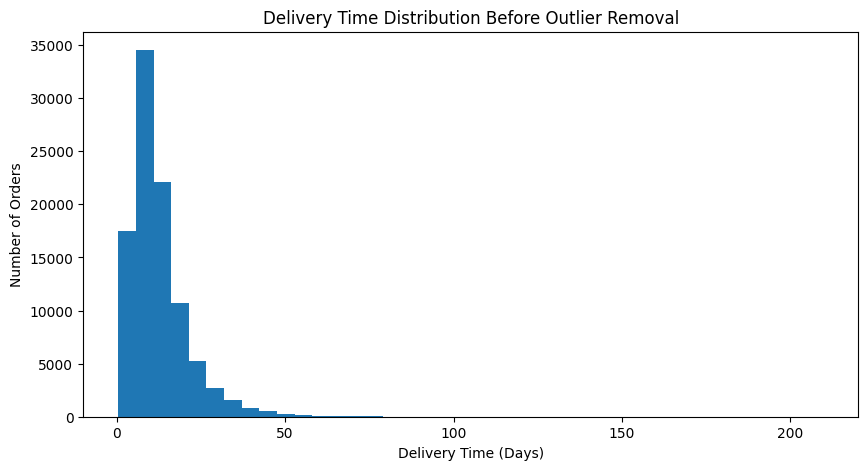

In [23]:
plt.figure(figsize=(10, 5))

plt.hist(
    orders_clean["delivery_days"],
    bins=40
)

plt.title("Delivery Time Distribution Before Outlier Removal")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.show()

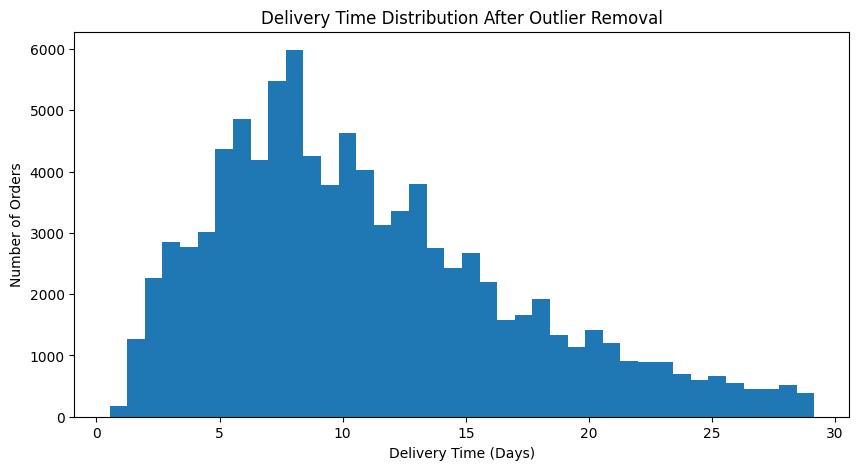

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(
    orders_processed["delivery_days"],
    bins=40
)

plt.title("Delivery Time Distribution After Outlier Removal")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.show()

In [25]:
print("FINAL DATA QUALITY CHECK")
print("-" * 40)

print("Dataset shape:", orders_processed.shape)

print("Duplicate rows:",
      orders_processed.duplicated().sum())

print("\nMissing values:")
print(
    orders_processed.isnull().sum()
    .sort_values(ascending=False)
    .head(10)
)

FINAL DATA QUALITY CHECK
----------------------------------------
Dataset shape: (91577, 12)
Duplicate rows: 0

Missing values:
order_approved_at                14
order_id                          0
order_status                      0
customer_id                       0
order_purchase_timestamp          0
order_delivered_carrier_date      0
order_delivered_customer_date     0
order_estimated_delivery_date     0
delivery_days                     0
is_late                           0
dtype: int64


In [26]:
print("FINAL DELIVERY STATISTICS")
print("-" * 40)

print(
    f"Average Delivery Time: "
    f"{orders_processed['delivery_days'].mean():.2f} days"
)

print(
    f"Median Delivery Time: "
    f"{orders_processed['delivery_days'].median():.2f} days"
)

print(
    f"Minimum Delivery Time: "
    f"{orders_processed['delivery_days'].min():.2f} days"
)

print(
    f"Maximum Delivery Time: "
    f"{orders_processed['delivery_days'].max():.2f} days"
)

print(
    f"Late Delivery Rate: "
    f"{orders_processed['is_late'].mean() * 100:.2f}%"
)

FINAL DELIVERY STATISTICS
----------------------------------------
Average Delivery Time: 11.05 days
Median Delivery Time: 9.91 days
Minimum Delivery Time: 0.53 days
Maximum Delivery Time: 29.15 days
Late Delivery Rate: 4.27%


In [27]:
orders_processed.to_csv(
    "week2_cleaned_orders.csv",
    index=False
)

print("Cleaned Week 2 dataset saved successfully!")

Cleaned Week 2 dataset saved successfully!


In [28]:
orders_processed.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late,delivery_days_normalized,delivery_days_standardized
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,0,0.276178,-0.429053
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,0,0.462977,0.448935
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,0,0.309643,-0.271761
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,0,0.442943,0.354773
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,0,0.081788,-1.342721
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,16.542245,0,0.559433,0.902298
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,9.989826,0,0.330457,-0.173932
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,9.818762,0,0.324479,-0.202030
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,18.221852,0,0.618128,1.178172
10,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,12.650937,0,0.423450,0.263153


## Week 2 Preprocessing Summary

The Week 2 preprocessing process included data collection, data inspection,
missing value analysis, duplicate detection, date conversion, delivery-time
calculation, invalid-value handling, outlier detection using the IQR method,
late-delivery identification, normalization, standardization, and final
data-quality validation.

The cleaned dataset is now prepared for further logistics analysis and
visualization in the upcoming internship weeks.